# TERM DEPOSIT SUBSCRIPTION PREDICTION
## Auther:Aiman Afzaal
## Internship Project
This project predicts whether a customer will subscribe to a term deposit using machine learning models.

# Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


### Importing Libraries

- pandas, numpy helps  data handling  
- matplotlib, seaborn helps visualization  
- sklearn helps machine learning models and evaluation metrics


# Load Dataset

In [6]:
df = pd.read_csv("bank.csv", sep=';')
print(df.head())
print(df.info())

   age          job  marital  education default  balance housing loan  \
0   30   unemployed  married    primary      no     1787      no   no   
1   33     services  married  secondary      no     4789     yes  yes   
2   35   management   single   tertiary      no     1350     yes   no   
3   30   management  married   tertiary      no     1476     yes  yes   
4   59  blue-collar  married  secondary      no        0     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome   y  
0  cellular   19   oct        79         1     -1         0  unknown  no  
1  cellular   11   may       220         1    339         4  failure  no  
2  cellular   16   apr       185         1    330         1  failure  no  
3   unknown    3   jun       199         4     -1         0  unknown  no  
4   unknown    5   may       226         1     -1         0  unknown  no  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #  

### Dataset Overview

- Dataset: Bank Marketing Dataset  
- Source: UCI Machine Learning Repository  
- Target variable:  (yes/no)

The dataset contains customer information such as age, job, marital status, and campaign details.

# Basic Information

In [8]:
print(df.shape)
print(df.info())
print(df.describe())

(4521, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB
None
               age       balance          day     duration     campaign  \
count  4

### Data Understanding

- The dataset contains multiple numerical and categorical features  
- No major missing values detected  
- Data types include integers and object (categorical values)

# Target Distribution

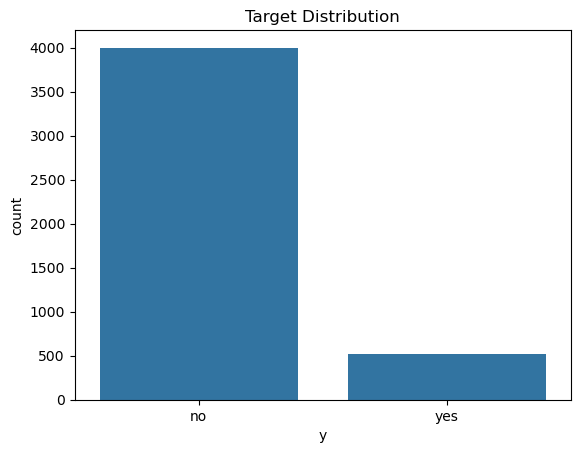

In [9]:
sns.countplot(x='y', data=df)
plt.title("Target Distribution")
plt.show()

### Exploratory Data Analysis (EDA)

- Majority of customers did not subscribe  
- Dataset is imbalanced

# Encoding 

In [10]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

### Data Preprocessing

Categorical variables were converted into numerical values using Label Encoding to make them suitable for machine learning models.

# Split Data

In [11]:
X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Train-Test Split

- 80% data used for training  
- 20% data used for testing

# Logistic Regression

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

### Logistic Regression

A baseline model used for binary classification. It predicts probability of subscription.

# Random Forest 

In [15]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

### Random Forest

An ensemble model that uses multiple decision trees to improve accuracy and reduce overfitting.

# Confusion Matrix

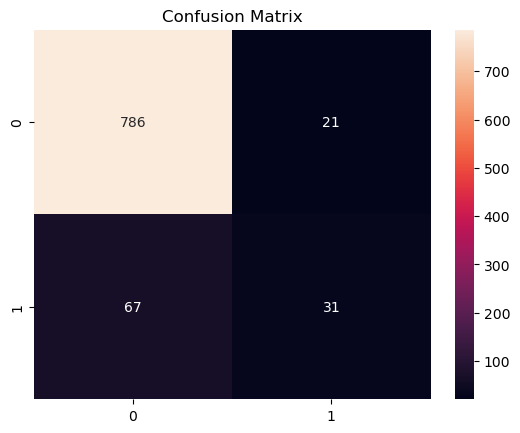

In [16]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

### Confusion Matrix

Shows correct and incorrect predictions:
- True Positives
- False Positives
- True Negatives
- False Negatives

# Classification Report 

In [17]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95       807
           1       0.60      0.32      0.41        98

    accuracy                           0.90       905
   macro avg       0.76      0.65      0.68       905
weighted avg       0.89      0.90      0.89       905



### Evaluation Metrics

- Precision means accuracy of positive predictions  
- Recall means  ability to find all positives  
- F1-score means  balance between precision and recall

# ROC Curve

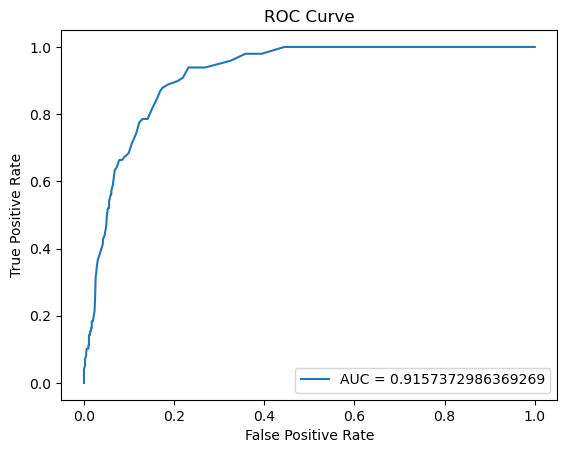

In [18]:
y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = " + str(roc_auc))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("ROC Curve")
plt.show()

### ROC Curve

- Shows performance of classification model  
- AUC closer to 1 indicates better performance

# Feature Importance

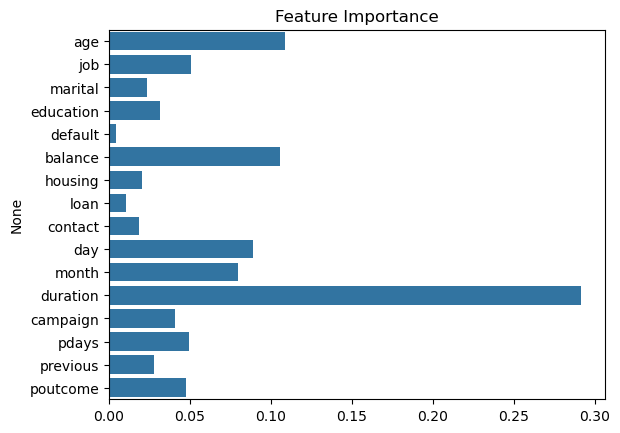

In [19]:
importances = rf.feature_importances_

sns.barplot(x=importances, y=X.columns)
plt.title("Feature Importance")
plt.show()

### Feature Importance

Identifies which features contribute most to prediction.

Important features often include:
- Duration
- Contact type
- Previous campaign outcome

### Conclusion

- Random Forest performed better than Logistic Regression  
- Key features influencing predictions were identified  
- Model can help banks target customers effectively  

### Business Insight:
- Customers with longer call duration are more likely to subscribe  
- Marketing strategy can be optimized using this model